# Projeto 1 - ANÁLISE DE CONTRATOS DE VENDAS

# Projeto: Análise de Faturamento e Desempenho de Vendas (2019)

Neste projeto, realizei a consolidação e análise de dados de uma empresa de prestação de serviços. O objetivo foi extrair indicadores-chave (KPIs) para dar suporte à decisão estratégica da Gerência Administrativa.

### 📊 Bases de Dados Utilizadas (Os dados referem-se às operações do ano de 2019, distribuídos em 3 Arquivos principais):
<br> Foram consolidados dados de diferentes setores da Empresa - RH e Comercial -, em formatos variados, de forma a simular um ambiente real de tratamento de dados.
1. **CadastroFuncionarios.csv**: Contém 9 colunas com informações de RH, incluindo a composição da remuneração total (Salário + Encargos).
2. **CadastroClientes.csv**: Contém a identificação dos clientes e os valores individuais de faturamento mensal contratado.
3. **BaseServicosPrestados.xlsx**: O arquivo transacional que conecta as bases anteriores por meio de IDs (`ID Funcionário` e `ID Cliente`), além de informar a duração de cada Contrato em vigor.

### 1. Importando as Bibliotecas necessárias para o Projeto:

Bibliotecas necessárias para tratamento dos dados em Python neste notebook:
- **pandas**: para manipulação e análise dos dados em formato de tabelas (DataFrames).  
- **matplotlib.pyplot**: para criar gráficos (com mais facilidades) e visualizar os resultados.  
- **seaborn**: usado como uma extensão da matplotlib, facilita a criação de gráficos estatísticos (histogramas). 
    - o comando sns.set_theme(style="whitegrid"): permite um estilo de gráficos com um fundo branco e linhas de grade cinzas, padronizando a forma de visualização dos Gráficos bem como facilitando a legibilidade.

In [1]:
#%pip install seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Configura o display para mostrar 2 casas decimais em todos os floats
#pd.options.display.float_format = '{:.2f}'.format

### 2. Carregando os Arquivos de Dados:<>
- **CadastroFuncionarios.csv;**
- **CadastroClientes.csv;**
- **BaseServicosPrestados.xlsx.**


Funções do pandas utilizadas:
- `pd.read_csv()` para ler arquivos em formato csv.  
- `pd.read_excel()` para ler arquivos em formato Excel. 

Para os arquivos CSV os seguintes comandos foram utilizados:
- sep=';' -> define o ponto e vírgula como separador
- encoding='utf-8' -> padrão comum para arquivos Excel/CSV brasileiros com acentos
- decimal=',' -> avisa o Python que a vírgula é o separador de casas decimais
- index_col=None -> garante que nenhuma coluna seja usada como índice automaticamente

Para o arquivo Excel:
- Como os Arquivos .xlsx já guardam a informação de tipo de dado internamente, o pandas costuma reconhecer os decimais automaticamente.
- servicos_df = pd.read_excel('BaseServicosPrestados.xlsx')

In [3]:
funcionarios_df = pd.read_csv(
    'CadastroFuncionarios.csv', 
    sep=';', 
    encoding='UTF-8', 
    decimal=',',
    index_col=None)

In [4]:
clientes_df = pd.read_csv(
    'CadastroClientes.csv', 
    sep=';', 
    encoding='UTF-8', 
    decimal=',',
    index_col=None)

In [5]:
servicos_df = pd.read_excel('BaseServiçosPrestados.xlsx')

### 3. Avaliando os DataFrames<br>
#### Verificando a Estrutura de Dados com .info()

Antes de iniciar a análise, é importante validar a estrutura dos dados carregados, ou seja, verificar se as colunas descritas no texto estão, realmente, presentes.  
Utilizando o comando `.info()`, é possível realizar as seguintes verificações:

- Quantidade de linhas e colunas em cada arquivo.  
- Nome das colunas disponíveis.  
- Tipo de dado de cada coluna (numérico, texto, etc.).  
- Quantidade de valores não nulos em cada coluna.  

Dessa forma, tem-se a confiança de que os arquivos foram lidos corretamente e, além disso, será possível identificar a necessidade ou não de possíveis ajustes.

In [6]:
print("--- Informações: Cadastro de Funcionários ---")
funcionarios_df.info()

print("\n--- Informações: Cadastro de Clientes ---")
clientes_df.info()

print("\n--- Informações: Base de Serviços Prestados ---")
servicos_df.info()

--- Informações: Cadastro de Funcionários ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID Funcionário  114 non-null    int64  
 1   Estado Civil    114 non-null    object 
 2   Nome Completo   114 non-null    object 
 3   Salario Base    114 non-null    int64  
 4   Impostos        114 non-null    float64
 5   Beneficios      114 non-null    float64
 6   VT              114 non-null    int64  
 7   VR              114 non-null    float64
 8   Cargo           114 non-null    object 
 9   Area            114 non-null    object 
dtypes: float64(3), int64(3), object(4)
memory usage: 9.0+ KB

--- Informações: Cadastro de Clientes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  -----

- O resultado do Excel foi truncado para não ocupar muito espaço. <br> 
- As colunas ID Cliente e Tempo Total de Contrato (Meses) foram identificadas como int64 o que possibilitará a realização de cálculos de Faturamento.<br> 
- As colunas Salario Base, Impostos, Beneficios, VT e VR estão com valores int64 ou float64, o que significa que o parâmetro decimal=',' funcionou e temos a garantia que o Python interpretou esses dados como números que podem ser objetos de cálculos aritméticos. <br>

Neste ponto, já estaria tudo "pronto" para iniciar a realização dos cálculos necessários para a Análise dos Contratos de Vendas, contudo, visando garantir que os dados estão consistentes e íntegros, realizei a operação de **"Data Cleaning & Quality Assurance"**. 

- A operação de **"Data Cleaning & Quality Assurance"** consiste na verificação e remoção de valores nulos, duplicados e inconsistências de grafia nas colunas categóricas, garantindo a integridade dos Indicadores-chave de Desempenho (KPIs) gerados. 
<br> Dessa forma, eliminei os dados com as seguintes características: 
    - **Erros de grafia** nas colunas ou valores.  
    - **Cabeçalhos deslocados** (quando o nome das colunas aparece como uma linha de dados).  
    - **Estrutura geral dos dados**, conferindo se cada tabela está organizada como esperado.


### 4. DATA CLEANING & QUALITY ASSURANCE

Para realizar uma "Limpeza Básica" (remoção de espaços em branco nos nomes das colunas e dentro das células de texto, exclusão de valores nulos, linhas vazias e duplicações) usei um "SCRIPT" de LIMPEZA e PADRONIZAÇÃO capaz de resolver essas possíveis inconsistências de uma única vez.

#### ***"SCRIPT" de LIMPEZA e PADRONIZAÇÃO***

##### **1. Removendo espaços em branco nos nomes das colunas** <br>
Às vezes 'ID Cliente' vem como 'ID Cliente ' (com um espaço no fim)

In [7]:
funcionarios_df.columns = funcionarios_df.columns.str.strip()
clientes_df.columns = clientes_df.columns.str.strip()
servicos_df.columns = servicos_df.columns.str.strip()

#### **2. Removendo espaços em branco dentro das células de texto** <br>
Isso evita que 'Marketing' seja diferente de 'Marketing    '

In [8]:
colunas_texto = ['Nome Completo', 'Cargo', 'Area']
for col in colunas_texto:
    if col in funcionarios_df.columns:
        funcionarios_df[col] = funcionarios_df[col].str.strip()

#### **3. Tratamento de Valores Nulos (Missing Data)** <br>
Verificando se há nulos e, por segurança, removendo linhas totalmente vazias.

In [9]:
funcionarios_df = funcionarios_df.dropna(how='all')
clientes_df = clientes_df.dropna(how='all')
servicos_df = servicos_df.dropna(how='all')

#### **4. Verificação de Dados Duplicados**
Havendo linhas 100% idênticas, mantive somente a primeira.

In [10]:
funcionarios_df = funcionarios_df.drop_duplicates()
clientes_df = clientes_df.drop_duplicates()
servicos_df = servicos_df.drop_duplicates()

In [11]:
print("✅ Limpeza básica concluída com sucesso!")

✅ Limpeza básica concluída com sucesso!


#### **5. Verificando se os arquivos foram importados corretamente e identificando possíveis problemas, como:**

- **Erros de grafia** nas colunas ou valores.  
- **Cabeçalhos deslocados** (quando o nome das colunas aparece como uma linha de dados).  
- **Estrutura geral dos dados**, conferindo se cada tabela está organizada como esperado.
- Para essa verificação convém mostrar separadamente as Tabelas Importadas:
    - Cadastro de Funcionários  
    - Cadastro de Clientes  
    - Base de Serviços Prestados 
        - usando o comando **head()** é possível ver o status das primeiras linhas de cada uma dessas Tabelas.

In [12]:
print("CADASTRO DE FUNCIONÁRIOS")
display(funcionarios_df.head())

print("- " *34)

print("CADASTRO DE CLIENTES")
display(clientes_df.head())

print("- " *34)
print("BASE SERVIÇOS PRESTADOS")
display(servicos_df.head())

CADASTRO DE FUNCIONÁRIOS


,ID Funcionário,Estado Civil,Nome Completo,Salario Base,Impostos,Beneficios,VT,VR,Cargo,Area
0,1,C,Gabriel Mesquita,21910,10955.0,4382.0,242,719.04,Diretor,Operações
1,2,C,João Haddad,5404,2702.0,1080.8,154,574.56,Estagiário,Logística
2,3,C,Amanda Marques Ribeiro,16066,8033.0,3213.2,154,729.12,Estagiário,Administrativo
3,4,C,Guilherme Nunez,21305,10652.5,4261.0,220,524.16,Analista,Administrativo
4,5,C,Adelino Gomes,5098,2549.0,1019.6,176,725.76,Analista,Administrativo


- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
CADASTRO DE CLIENTES


,ID Cliente,Cliente,Valor Contrato Mensal
0,1,Teixeira Gonçalves,540
1,2,Souza Santos,1260
2,3,Emídio Alves,3195
3,4,Santos Costa,2520
4,5,Do Monteiro,3510


- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
BASE SERVIÇOS PRESTADOS


,Codigo do Servico,ID Funcionário,ID Cliente,Tempo Total de Contrato (Meses)
0,OS0001,67,1,14
1,OS0002,17,2,12
2,OS0003,116,4,14
3,OS0004,37,5,8
4,OS0005,130,6,8


#### **6. Por último, para garantir que os nomes das áreas estão corretos (sem erros de digitação):**

In [13]:
print("Áreas encontradas:")
print(funcionarios_df['Area'].unique())

Áreas encontradas:
['Operações' 'Logística' 'Administrativo' 'Financeiro' 'Comercial']


### 5. CONSOLIDAÇÃO (Merge) DOS DADOS PARA REALIZAÇÃO DOS CÁLCULOS: 
- (Operação de '**"Inner Join"**' para combinar as linhas de 2 Tabelas (Dataframes) usando uma coluna comum. Isso possibilitará a realização de Análises Multidimensionais por Área, por Cliente, Tempo)  
- Os seguintes Cálculos foram realizados após a operação '**"Inner Join"**:
    - Valor Total da Folha Salarial da Empresa 
    - Faturamento Total da Empresa
    - Percentual de Funcionários que fecharam Contratos 
    - Quantidades de Contratos fechados por Áreas da Empresa
    - Quantidades de Funcionários por Áreas da Empresa
    - Faturamento Médio Mensal dos Contratos fechados pela Empresa

5.1 Unindo a base de serviços com a base de clientes
- Usei o 'ID Cliente' como elo de ligação

In [14]:
servicos_consolidado = servicos_df.merge(clientes_df, on='ID Cliente')

5.2 Unindo o resultado acima com a base de funcionários
- Usei o 'ID Funcionário' como elo de ligação

In [15]:
servicos_consolidado = servicos_consolidado.merge(funcionarios_df, on='ID Funcionário')

5.3 Visualizando as primeiras linhas da nossa tabela mestre


In [16]:
display(servicos_consolidado.head())

,Codigo do Servico,ID Funcionário,ID Cliente,Tempo Total de Contrato (Meses),Cliente,Valor Contrato Mensal,Estado Civil,Nome Completo,Salario Base,Impostos,Beneficios,VT,VR,Cargo,Area
0,OS0001,67,1,14,Teixeira Gonçalves,540,C,Carla Amiccuci Areias,12054,6027.0,2410.8,308,829.92,Coordenador,Financeiro
1,OS0002,17,2,12,Souza Santos,1260,S,Pedro Carrera,15718,7859.0,3143.6,176,628.32,Coordenador,Logística
2,OS0003,116,4,14,Santos Costa,2520,C,Bruno Cunha Felippe,21154,10577.0,4230.8,198,792.96,Analista,Logística
3,OS0004,37,5,8,Do Monteiro,3510,C,Marcos Almeida Albuquerque Faria,3398,1699.0,679.6,242,540.96,Analista,Financeiro
4,OS0005,130,6,8,Soares Lobo,2340,S,Mylena Pinheiro Mariano,5818,2909.0,1163.6,242,598.08,Coordenador,Comercial


5.4 Criando as Tabelas Consolidadas (MERGE) para a Realização dos Cálculos:
- Unindo Serviços com Clientes (para ter o valor do contrato)

In [17]:
servicos_clientes = servicos_df.merge(clientes_df, on='ID Cliente')

- Unindo o resultado anterior com Funcionários (para identificar a Área de quem prestou o serviço)

In [18]:
base_completa = servicos_clientes.merge(funcionarios_df, on='ID Funcionário')

### 6. VALOR TOTAL DA FOLHA SALARIAL DA EMPRESA: 

Os Salários totais de cada funcionário compreendem: 
- Salário Base; 
- Impostos; 
- Vale Refeição (VR); 
- Vale Transporte (VT); 
- Benefícios.

Assim, após realizar a Soma desses componentes para cada Funcionário, somei todos os Salários dos Funcionários. <br>
- Utilizando o comando `.sum()` da Biblioteca **pandas** calculei todos esses custos (e o custo total da Folha de Salários)

In [19]:
# Somamos todos os custos por funcionário
funcionarios_df['Custo Total'] = ( 
    funcionarios_df['Salario Base'] + 
    funcionarios_df['Impostos'] + 
    funcionarios_df['Beneficios'] +
    funcionarios_df['VT'] + 
    funcionarios_df['VR'] )


total_folha = funcionarios_df['Custo Total'].sum()
print(f"1. Valor Total da Folha Salarial da Empresa: R$ {total_folha:,.2f}")

1. Valor Total da Folha Salarial da Empresa: R$ 2,717,493.22


### 7. FATURAMENTO TOTAL DA EMPRESA: 

Usando o Resultado da operação de MERGE (unificação) das Tabelas Clientes e Serviços (ID do Cliente) realizei a Operação de cálculo do Faturamento Total da Empresa:<br>

Primeiramente, foi calculado o Valor Total gerado por cada um dos Contratos multiplicando o Valor Mensal pela duração total (em meses). 
- Valor Total Contrato = Valor Mensal * Tempo de duração Contrato (meses) <br>

O Faturamento Total da Empresa corresponde ao Somatório dos Valores Totais dos Contratos.

In [20]:
servicos_clientes['Faturamento Individual'] = servicos_clientes['Tempo Total de Contrato (Meses)'] * servicos_clientes['Valor Contrato Mensal']

total_faturamento = servicos_clientes['Faturamento Individual'].sum()
print(f"2. Faturamento Total da Empresa: R$ {total_faturamento:,.2f}")

2. Faturamento Total da Empresa: R$ 5,519,160.00


### 8. PERCENTUAL DE FUNCIONÁRIOS QUE FECHARAM CONTRATOS: 

O cuidado neste cálculo foi o de não contabilizar o mesmo funcionário, várias vezes, na base de serviços. 
<br> Usando o comando unique() foi possível evitar essa contagem em duplicidade.
<br> O comando `len()` contabiliza quantos funcionários distintos já fecharam contratos.

In [21]:
funcionarios_com_contrato = len(servicos_df['ID Funcionário'].unique())
print(f"1. Quantidade de funcionários que já fecharam contratos é: {funcionarios_com_contrato}.") 

total_funcionarios = len(funcionarios_df['ID Funcionário'])
print(f"2. Total de Funcionários na Empresa é: {total_funcionarios}.")

percentual = funcionarios_com_contrato / total_funcionarios
print(f"3. Percentual de funcionários com Contratos Fechados: {percentual:.2%}")

1. Quantidade de funcionários que já fecharam contratos é: 99.
2. Total de Funcionários na Empresa é: 114.
3. Percentual de funcionários com Contratos Fechados: 86.84%


### 9. QUANTIDADES DE CONTRATOS FECHADOS POR ÁREAS DA EMPRESA:<br> 
Usando a mesma Base que unificou Serviços por Funcionários foi possível realizar os cálculos:

Como o resultado de um value_counts() será sempre uma SERIES, que é uma coluna de dados que transforma a coluna da categoria do agrupamento em uma coluna de índice, é necessário usar no final do código o comando `.reset_index()` para colocar a coluna de categoria como uma coluna comum novamente, permitindo que a exportação desse DataFrame num formato em que o Power BI e o Excel possam interpretá-lo.<br> 
Para análise e cálculos rápidos, a Series quebra o galho, todavia, para construir Gráficos e Dashboards, o DataFrame é obrigatório.

In [22]:
contratos_por_area = base_completa['Area'].value_counts().reset_index()

# Renomeando para o Dashboard não ficar com nomes genéricos como "count" ou "index"
# Usando o .Columns
contratos_por_area.columns = ['Area', 'Qtd_Contratos']

print("\n4. Total de contratos por área:")
display(contratos_por_area)


4. Total de contratos por área:


,Area,Qtd_Contratos
0,Administrativo,63
1,Operações,48
2,Comercial,44
3,Financeiro,42
4,Logística,40


### 10. QUANTIDADES DE FUNCIONÁRIOS POR ÁREAS DA EMPRESA: <br> 
Usando, também, a mesma Base que unificou Serviços por Funcionários foi possível realizar os cálculos:

In [23]:
funcionarios_por_area = funcionarios_df['Area'].value_counts().reset_index()

# Renomeando para o Dashboard não ficar com nomes genéricos como "count" ou "index"
# Usando o .Columns
funcionarios_por_area.columns = ['Area', 'Qtd_Funcionarios']

print("\n5. Total de funcionários por área:")
display(funcionarios_por_area)


5. Total de funcionários por área:


,Area,Qtd_Funcionarios
0,Administrativo,26
1,Comercial,26
2,Operações,23
3,Logística,21
4,Financeiro,18


### 11. FATURAMENTO MÉDIO MENSAL DOS CONTRATOS FECHADOS PELA EMPRESA: <br> 
Refere-se à média da coluna 'Valor Contrato Mensal' na tabela de clientes:

In [24]:
ticket_medio = clientes_df['Valor Contrato Mensal'].mean()
print(f"\n6. Ticket Médio Mensal: R$ {ticket_medio:,.2f}")


6. Ticket Médio Mensal: R$ 2,502.56


### 12. EFICIÊNCIA OPERACIONAL - FATURAMENTO X CUSTOS: <br> 
- O Objetivo desta Avaliação foi descobrir quais são as áreas mais Lucrativas da Empresa. <br> 
- A identificação dos Funcionários com melhor desempenho também foi um índice de Análise de Contratos avaliado. <br>
- Além disso, a Duração Média dos Contratos por Área foi outro parâmetro avaliado.

### 12.1 Calculando faturamento por área 


In [25]:
# 1. Para evitar Erros de busca, procurei garantir que o Merge foi feito
servicos_clientes = servicos_df.merge(clientes_df, on='ID Cliente')
base_completa = servicos_clientes.merge(funcionarios_df, on='ID Funcionário')

# 2. Criei a coluna de Faturamento DIRETAMENTE na base_completa, garantindo que o Python vai conseguir enxergar a coluna.
# Assim não tem erro: se a coluna acabou de ser criada, o Python vai encontrá-la
base_completa['Faturamento Individual'] = base_completa['Tempo Total de Contrato (Meses)'] * base_completa['Valor Contrato Mensal']

# 3. Com essa garantia de que o Python enxergou a coluna de Faturamento, realizei o agrupamento para iniciar os cálculos:
faturamento_por_area = base_completa.groupby('Area')['Faturamento Individual'].sum().reset_index()


# 3.1. Aplicamos o rename para profissionalizar o cabeçalho
faturamento_por_area = faturamento_por_area.rename(columns={ 'Coluna_Numerica_Existente': 'Faturamento_Individual' })
display(faturamento_por_area)


# 4. Calculando o custo da folha (já tendo a certeza que Custo Total existe em funcionarios_df):
custo_por_area = funcionarios_df.groupby('Area')['Custo Total'].sum().reset_index()

# 4.1. Aplicamos o rename para profissionalizar o cabeçalho
custo_por_area = custo_por_area.rename(columns={'Coluna_Numerica_Existente': 'Custo Total' })
display(custo_por_area)

print("✅ Problema resolvido! Faturamento e Custo calculados por área.")




,Area,Faturamento Individual
0,Administrativo,1527750
1,Comercial,1077660
2,Financeiro,899910
3,Logística,871110
4,Operações,1142730


,Area,Custo Total
0,Administrativo,686016.38
1,Comercial,524104.86
2,Financeiro,336846.34
3,Logística,563740.42
4,Operações,606785.22


✅ Problema resolvido! Faturamento e Custo calculados por área.


A área de Administrativo fechou o maior volume de contratos, porém apresenta o maior custo por área.

In [26]:
# 5 --- CONEXÃO DE BASES (UNIÃO DAS TABELAS) ---
# Criamos um novo DataFrame fruto da união de dois outros
comparativo_area = faturamento_por_area.merge(
custo_por_area[['Area', 'Custo Total']], # Selecionamos apenas o necessário da Tabela B
on='Area', # A coluna que existe nas duas tabelas e serve de "ponte"
how='inner' # O modo de junção (inner, left, right ou outer)
).sort_values(by='Custo Total', ascending=False)

#Arredondando os valores
comparativo_area_area=comparativo_area.round(2) 

# Tabela com Faturamento Individual e Custo Total por Área 
print("\n--- Análise de Margem por Área ---")
display(comparativo_area)


--- Análise de Margem por Área ---


,Area,Faturamento Individual,Custo Total
0,Administrativo,1527750,686016.38
4,Operações,1142730,606785.22
3,Logística,871110,563740.42
1,Comercial,1077660,524104.86
2,Financeiro,899910,336846.34


### 12.2 Calculando o Ranking de Desempenho (Top 5 Funcionários)

In [27]:
top_vendedores = base_completa.groupby('Nome Completo')['Faturamento Individual'].sum().sort_values(ascending=False).reset_index()

#Arredondando os valores
top_vendedores=top_vendedores.round(2) 

print("\n--- Top 5 Funcionários (Faturamento) ---")
display(top_vendedores.head(5))


--- Top 5 Funcionários (Faturamento) ---


,Nome Completo,Faturamento Individual
0,Rodrigo e Silva Lemos,144810
1,Carolina Monteiro,126000
2,Andre Ramos,123930
3,Roberto Suzano,117900
4,Matheus Sepúlveda,117810


### 12.3 Duração Média dos Contratos por Área

In [28]:
duracao_media = base_completa.groupby('Area')['Tempo Total de Contrato (Meses)'].mean().sort_values(ascending=False).reset_index()
#Arredondando os valores
duracao_media=duracao_media.round(2) 

print("\n--- Duração Média de Contrato (Meses) por Área ---")
display(duracao_media)


--- Duração Média de Contrato (Meses) por Área ---


,Area,Tempo Total de Contrato (Meses)
0,Logística,10.00
1,Comercial,9.91
2,Operações,9.75
3,Administrativo,9.52
4,Financeiro,9.14


### 13. Para facilitar o entendimento dos Indicadores-chave de Desempenho (KPIs) gerei Gráficos para cada um dos KPIs contabilizados.<br> 
A importação das Libraries para geração de Gráficos já foi realizada no primeiro passo deste projeto. 

### 13.1 PERCENTUAL DE FUNCIONÁRIOS QUE JÁ FECHARAM CONTRATO: <br> 
Escolhi o Gráfico de Rosca (Donut Chart) - (Em vez do Gráfico de Pizza, pois o Foco nessa plotagem é na Proporção)

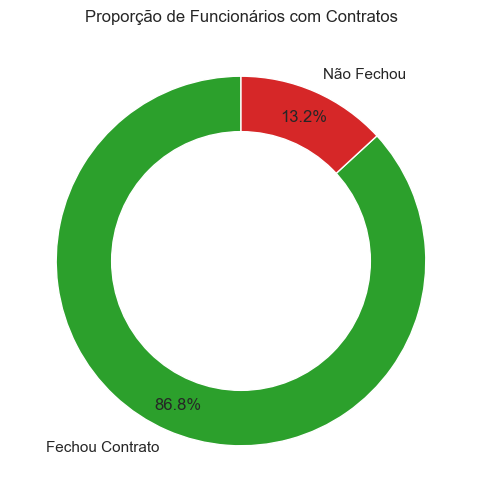

In [29]:
labels = ['Fechou Contrato', 'Não Fechou']
valores = [percentual, 1 - percentual]
cores = ['#2ca02c', '#d62728'] # Verde e Vermelho suave

plt.figure(figsize=(6, 6))
plt.pie(valores, labels=labels, autopct='%1.1f%%', startangle=90, colors=cores, pctdistance=0.85)
# Criando o círculo central (o "furo" da rosca)
centro = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro)

plt.title("Proporção de Funcionários com Contratos")
plt.show()

### 13.2 CONTRATOS POR ÁREA e FUNCIONÁRIOS POR ÁREA: 
<br> Optei pelo Gráfico de Barras Horizontais por facilitar a leitura dos nomes das áreas.

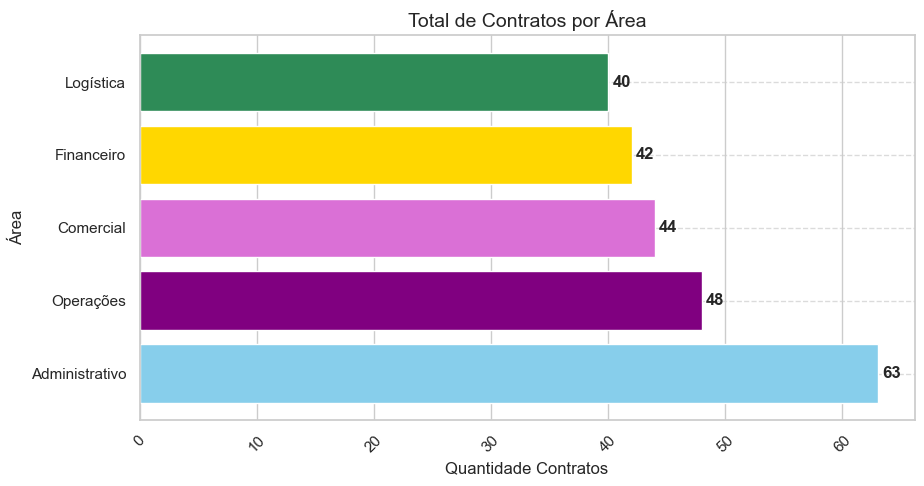

In [30]:
# --- TEMPLATE DE GRÁFICO PADRÃO ---

# 1. Definir os dados (Troque 'Area' e 'Faturamento' pelas suas colunas)
eixo_x = contratos_por_area['Qtd_Contratos']
eixo_y = contratos_por_area['Area']

# 2. Criar a figura
plt.figure(figsize=(10, 5)) # Define o tamanho da imagem

# 3 Definindo a lista de cores (uma para cada barra ou coluna ou fatia da pizza)
minhas_cores = ['skyblue', 'purple', 'orchid', 'gold', 'seagreen']

#4. ESCOLHER O TIPO DE GRÁFICO (Descomente apenas um abaixo):
# retorno = plt.bar(eixo_x, eixo_y, color=minhas_cores) # Para COLUNAS. Para passarmos as cores usamos color no singular.
retorno = plt.barh(eixo_y, eixo_x, color=minhas_cores) # Para BARRAS (Horizontal). Para passarmos as cores usamos color no singular.
# retorno = plt.plot(eixo_x, eixo_y, marker='o', ls='-') # Para LINHAS
# retorno = plt.pie(eixo_y, labels=eixo_x, autopct='%1.1f%%', colors=minhas_cores) # Para PIZZA. Para passarmos as cores usamos colors no plural.


# 5 --- RÓTULOS --- 
plt.bar_label(retorno, padding=3, fmt='%.f', fontweight='bold')


# 6. Personalização (Obrigatório para um visual profissional)
plt.title('Total de Contratos por Área', fontsize=14)
plt.xlabel('Quantidade Contratos')
plt.ylabel('Área') #É o eixo vertical
plt.xticks(rotation=45) # Inclina os nomes para não encavalar
plt.grid(axis='y', linestyle='--', alpha=0.7) # Linhas de fundo para facilitar a leitura


# 7. Exibir
plt.show()

### 13.3) Gráfico Funcionários por Área
Optei pelo gráfico de colunas para visualização da quantidade de funcionários por área.

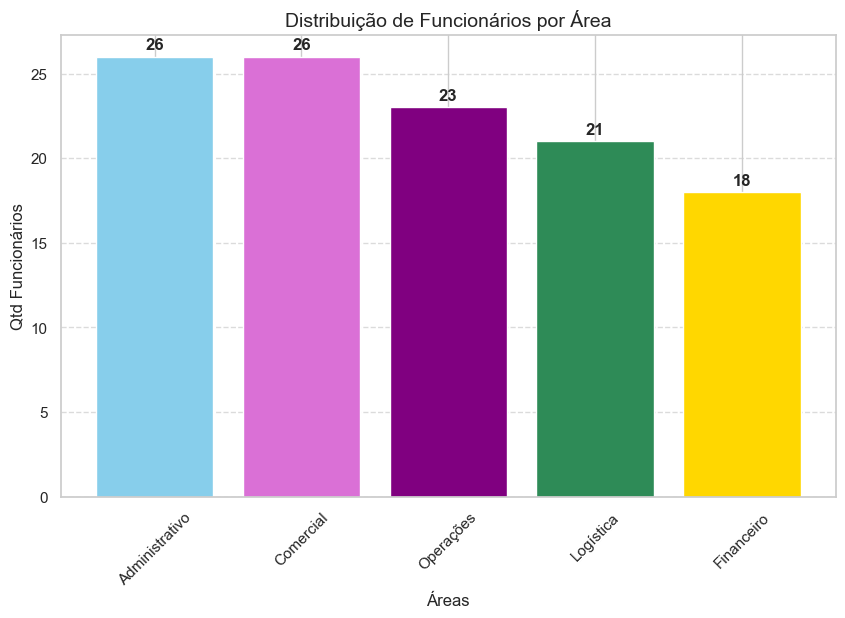

In [31]:
# Gráfico de Funcionários por Área
# --- TEMPLATE DE GRÁFICO PADRÃO ---

# 1. Definir os dados (Troque 'Area' e 'Faturamento' pelas suas colunas)
eixo_x = funcionarios_por_area['Area']
eixo_y = funcionarios_por_area['Qtd_Funcionarios']

# 2. Criar a figura
plt.figure(figsize=(10, 6)) # Define o tamanho da imagem

# 3 Definindo a lista de cores (uma para cada barra ou coluna ou fatia da pizza) 
minhas_cores = ['skyblue', 'orchid', 'purple', 'seagreen', 'gold']

# 4. ESCOLHER O TIPO DE GRÁFICO (Descomente apenas um abaixo):
retorno = plt.bar(eixo_x, eixo_y, color=minhas_cores)        # Para COLUNAS. Para passarmos as cores usamos color no singular.
# retorno = plt.barh(eixo_y, eixo_x, color=minhas_cores)      # Para BARRAS (Horizontal). Para passarmos as cores usamos color no singular.
# retorno = plt.plot(eixo_x, eixo_y, marker='o', ls='-')  # Para LINHAS
# retorno = plt.pie(eixo_y, labels=eixo_x, autopct='%1.1f%%', colors=minhas_cores) # Para PIZZA. Para passarmos as cores usamos colors no plural. 

# 5.--- RÓTULOS --- 
plt.bar_label(retorno, padding=3, fmt='%.f', fontweight='bold')

# 6. Personalização (Obrigatório para um visual profissional)
plt.title('Distribuição de Funcionários por Área', fontsize=14)
plt.xlabel('Áreas')
plt.ylabel('Qtd Funcionários') #É o eixo vertical
plt.xticks(rotation=45) # Inclina os nomes para não encavalar
plt.grid(axis='y', linestyle='--', alpha=0.7) # Linhas de fundo para facilitar a leitura

# 7. Exibir
plt.show()


### 13.3 FATURAMENTO MÉDIO MENSAL (Ticket Médio) DA EMPRESA: 
<br> Optei pelo Gráfico de Barras Horizontais para poder comparar o ticket Médio por Área (Se fosse apenas um Valor seria usado um "Indicador Card").



,Area,Valor Contrato Mensal
0,Administrativo,2512.14
1,Operações,2477.81
2,Comercial,2466.82
3,Financeiro,2392.50
4,Logística,2291.62


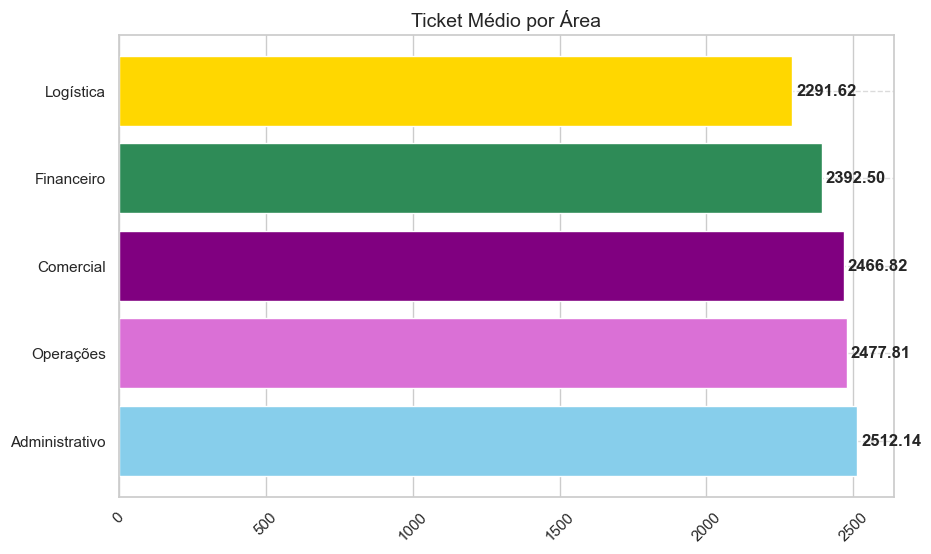

In [32]:
# Calculando ticket médio por área para expandir o gráfico
ticket_por_area = base_completa.groupby('Area')['Valor Contrato Mensal'].mean().sort_values(ascending=False).reset_index()

#Arredondando os valores
ticket_por_area=ticket_por_area.round(2) 

display(ticket_por_area)

# --- TEMPLATE DE GRÁFICO PADRÃO ---

# 1. Definir os dados (Troque 'Area' e 'Faturamento' pelas suas colunas)
eixo_x = ticket_por_area['Valor Contrato Mensal']
eixo_y = ticket_por_area['Area']

# 2. Criar a figura
plt.figure(figsize=(10, 6)) # Define o tamanho da imagem

# 3 Definindo a lista de cores (uma para cada barra ou coluna ou fatia da pizza) 
minhas_cores = ['skyblue', 'orchid', 'purple', 'seagreen', 'gold']

# 4. ESCOLHER O TIPO DE GRÁFICO (Descomente apenas um abaixo):
# retorno = plt.bar(eixo_x, eixo_y, color=minhas_cores)        # Para COLUNAS. Para passarmos as cores usamos color no singular.
retorno = plt.barh(eixo_y, eixo_x, color=minhas_cores)      # Para BARRAS (Horizontal). Para passarmos as cores usamos color no singular.
# retorno = plt.plot(eixo_x, eixo_y, marker='o', ls='-')  # Para LINHAS
# retorno = plt.pie(eixo_y, labels=eixo_x, autopct='%1.1f%%', colors=minhas_cores) # Para PIZZA. Para passarmos as cores usamos colors no plural. 

# 5.--- RÓTULOS --- 
plt.bar_label(retorno, padding=3, fmt='%.2f', fontweight='bold')

# 6. Personalização (Obrigatório para um visual profissional)
plt.title('Ticket Médio por Área', fontsize=14)
#plt.xlabel('Ticket Médio por Área')
#plt.ylabel('Áreas') #É o eixo vertical
plt.xticks(rotation=45) # Inclina os nomes para não encavalar
plt.grid(axis='y', linestyle='--', alpha=0.7) # Linhas de fundo para facilitar a leitura

# 7. Exibir
plt.show()


### 13.4 CUSTO DA FOLHA DE PAGAMENTO POR ÁREA: 
<br> Optei em usar um Gráfico de Barras Verticais 

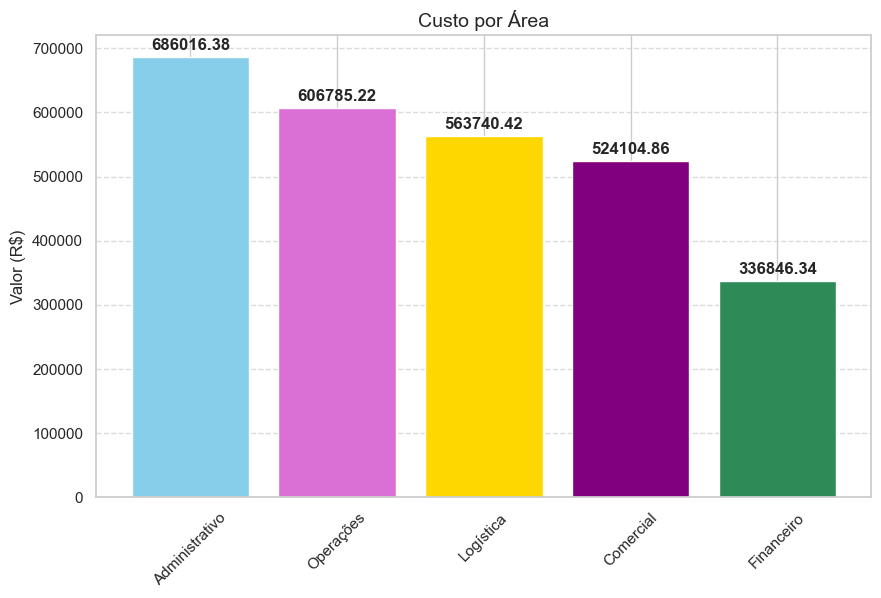

In [33]:
# --- TEMPLATE DE GRÁFICO PADRÃO ---

# Ordenando o Ticket Médio por Área de forma decrescente (ascending=False) 
custo_por_area = custo_por_area.sort_values(by='Custo Total', ascending=False)

# 1. Definir os dados (Troque 'Area' e 'Faturamento' pelas suas colunas)
eixo_x = custo_por_area['Area']
eixo_y = custo_por_area['Custo Total']

# 2. Criar a figura
plt.figure(figsize=(10, 6)) # Define o tamanho da imagem

# 3 Definindo a lista de cores (uma para cada barra ou coluna ou fatia da pizza) 
minhas_cores = ['skyblue', 'orchid', 'gold', 'purple', 'seagreen']

# 4. ESCOLHER O TIPO DE GRÁFICO (Descomente apenas um abaixo):
retorno = plt.bar(eixo_x, eixo_y, color=minhas_cores)        # Para COLUNAS. Para passarmos as cores usamos color no singular.
# retorno = plt.barh(eixo_y, eixo_x, color=minhas_cores)      # Para BARRAS (Horizontal). Para passarmos as cores usamos color no singular.
# retorno = plt.plot(eixo_x, eixo_y, marker='o', ls='-')  # Para LINHAS
# retorno = plt.pie(eixo_y, labels=eixo_x, autopct='%1.1f%%', colors=minhas_cores) # Para PIZZA. Para passarmos as cores usamos colors no plural. 

# 5.--- RÓTULOS --- 
plt.bar_label(retorno, padding=3, fmt='%.2f', fontweight='bold')

# 6. Personalização (Obrigatório para um visual profissional)
plt.title('Custo por Área', fontsize=14)
#plt.xlabel('Legenda do Eixo X')
plt.ylabel('Valor (R$)') #É o eixo vertical
plt.xticks(rotation=45) # Inclina os nomes para não encavalar
plt.grid(axis='y', linestyle='--', alpha=0.7) # Linhas de fundo para facilitar a leitura

# 7. Exibir
plt.show()


### 13.5 DataFrame Comparativo - FATURAMENTO x CUSTO 
<br> Optei em usar um Gráfico de Barras Agrupadas (Clustered bar chart)


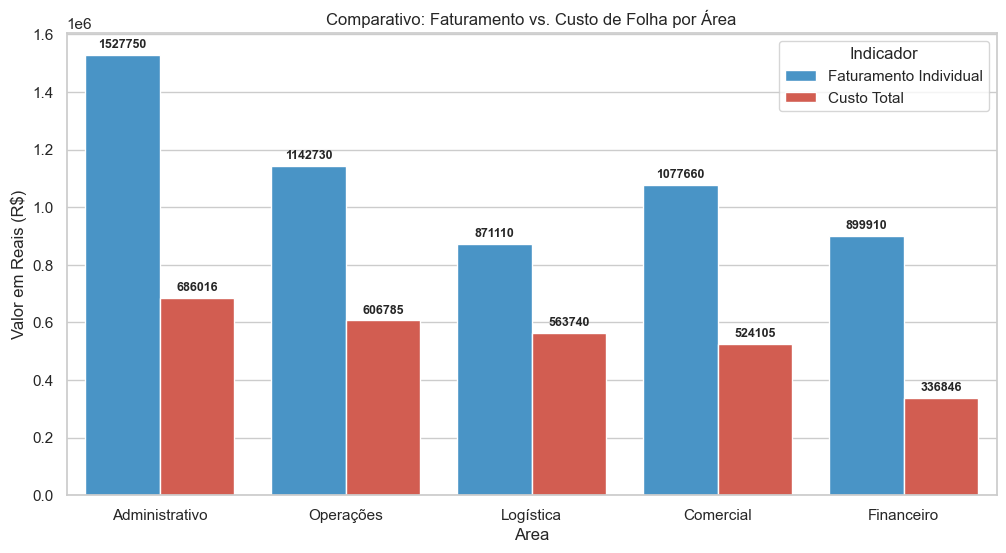

In [34]:
# Precisamos "derreter" (melt) o dataframe para o seaborn entender
comparativo_plot = comparativo_area.reset_index().melt(id_vars='Area', value_vars=['Faturamento Individual', 'Custo Total'])

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=comparativo_plot, x='Area', y='value', hue='variable', palette=['#3498db', '#e74c3c'])

# 2. LINHAS MÁGICAS PARA OS RÓTULOS:
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.0f', fontweight='bold', fontsize=9)

plt.title("Comparativo: Faturamento vs. Custo de Folha por Área")
plt.ylabel("Valor em Reais (R$)")
plt.legend(title="Indicador")


plt.show()

# **Conclusão e Recomendações Estratégicas** 

- Este projeto de análise de dados, desenvolvido integralmente em Python, teve como objetivo transformar Dados Brutos de RH e Faturamento de uma Empresa em inteligência estratégica para tomada de decisão. Através de um fluxo estruturado de tratamento e análise de dados, foi possível identificar oportunidades claras de Otimização de Custos e Alavancagem de Receita. <br>

### Principais Insights <br>

- Excelência Operacional: a área Financeira destaca-se como o benchmarking da Organização. Com a estrutura mais enxuta, apresenta a melhor relação entre faturamento e custo (267%), servindo, portanto, como modelo de eficiência para os demais setores.
- Desempenho das Áreas da empresa: a área **Administrativa** demonstrou ser a principal alavanca de Receita, apresentando o maior faturamento absoluto e mantendo uma excelente margem de performance.
- Oportunidades de Otimização: setores como Logística e Operações apresentam uma relação custo-benefício abaixo da média (155% e 188%, respectivamente). Esses setores devem ser priorizados em uma revisão de processos para aumentar a Rentabilidade sem necessariamente elevar os custos operacionais.

### Tabela de Eficiência por Área: abaixo, a síntese do desempenho financeiro por Área da Empresa:


| Área     | Faturamento Total (R$)| Custo Total (R$)| Eficiência (Faturamento/Custo) (%)|
| :---: | :---: | :---: | :---: |
|Financeiro| 899.910,00| 336.846,34 | **267** |
| **Administrativo** | **1.527.750,00** | 686.016,38 | 223 |
| Comercial | 1.077.660,00 | 524.104,86 | 206 |
| Operações| 1.142.730,00 | 606.785,22 | 188 |
| Logística | 871.110,00 | 563.740,42 | 155 |

# ***Plano de Ação Recomendado*** <br>
## **1.	📈 Benchmarking Interno:** Implementar o modelo de gestão do Financeiro em outras áreas para identificar quais práticas podem ser replicadas para reduzir custos sem perder performance.<br>
## **2.	📚 Mentoria e Transferência de Conhecimento:** Mapear os processos dos colaboradores de alta performance (maior faturamento individual) e criar um programa de mentoria para nivelar a produtividade das equipes de Operações e Logística.<br>
## **3. 📑 Revisão de Processos:** Realizar um estudo detalhado dos custos operacionais da Logística, visando identificar desperdícios que impactam a eficiência do faturamento.